# Maîtrise statistique des procédés de l'épaisseur de revêtement sur plusieurs lignes de production avec PROC BOXPLOT

## Résumé

Ce notebook utilise **PROC BOXPLOT** pour réaliser une maîtrise statistique des procédés (SPC) sur une mesure d'épaisseur de revêtement critique pour la qualité, collectée sur quatre lignes de production parallèles. Nous générons des données de mesure synthétiques en ligne, nous profilons les lignes avec `PROC MEANS`, et nous traçons des boîtes à moustaches squelettiques et schématiques qui comparent la position, la dispersion et les queues des différentes lignes sur un même graphique.

Nous évaluons ensuite chaque ligne par rapport à la spécification d'ingénierie (cible 50.00 mm, limites 49.80–50.20 mm) directement à partir du jeu de données de statistiques **`OUTBOX=`** — les quartiles exacts, les moustaches et les extrémités des moustaches derrière chaque boîte — et nous démontrons enfin l'aller-retour **`OUTHISTORY=` / `HISTORY=`** : PROC BOXPLOT exporte une ligne de synthèse compacte par ligne de production, et un second PROC BOXPLOT reconstruit un graphique identique directement à partir de cette synthèse, le schéma qu'utilise un tableau de bord SPC quotidien pour retracer sans réanalyser les mesures brutes.

Sur les quatre lignes, **LINE-A est la mieux centrée** sur la cible (moyenne 50.008 mm), **LINE-C tourne bas** (moyenne 49.932 mm, dérivant vers la LSL), et **LINE-D tourne à la fois haut et de façon la plus variable** (moyenne 50.102 mm, écart-type 0.080 mm) — son maximum de 50.248 mm est la seule observation qui franchit la limite de spécification supérieure de 50.20 mm.

## Sources de données

Toutes les données sont synthétiques et générées en ligne par la première étape DATA à l'aide de `call streaminit(20250531)` et `rand()`. Aucune entrée externe ou réseau n'est utilisée. La graine fixe rend chaque nombre de ce notebook reproductible.

**Jeu de données : `ProcessMeas`** (une ligne par pièce mesurée)

| Variable | Type | Description |
|----------|------|-------------|
| `Line` | Char(6) | Identifiant de ligne de production : `LINE-A`, `LINE-B`, `LINE-C`, `LINE-D` (la variable de groupe/classification) |
| `Shift` | Num | Indice de poste de production 1–6 (introduit une légère dérive entre postes) |
| `Thickness` | Num | Épaisseur de revêtement en mm (la variable d'analyse) ; cible 50.00 mm, limites de spécification 49.80–50.20 mm |

Chaque ligne est centrée sur une moyenne légèrement différente (50.00 / 50.04 / 49.92 / 50.10) avec une variation propre à la ligne, imitant les différences réelles d'un équipement à l'autre, et `LINE-B` injecte occasionnellement une petite excursion positive. L'étape DATA boucle sur six postes et quatre lignes avec des tailles de sous-groupes d'environ 18–25 pièces chacun ; dans cet environnement sans licence, le moteur plafonne la sortie aux **100 premières observations**, ce qui donne ici **38 / 19 / 21 / 22** pièces pour LINE-A à LINE-D — encore largement suffisant pour peupler quatre boîtes bien définies.

# Maîtrise statistique des procédés de l'épaisseur de revêtement avec PROC BOXPLOT

Dans la fabrication en grand volume, une boîte à moustaches est l'outil de prédilection de la SPC en atelier : elle résume la tendance centrale, la dispersion et les valeurs aberrantes d'une caractéristique de qualité pour chaque unité de production sur un seul graphique. Ici, nous surveillons l'**épaisseur de revêtement (mm)** d'une pièce produite en parallèle sur quatre lignes (`LINE-A` à `LINE-D`). La spécification d'ingénierie est une cible de **50.00 mm** avec une limite de spécification inférieure (LSL) de **49.80 mm** et une limite de spécification supérieure (USL) de **50.20 mm**.

Nous allons :

1. Générer un jeu de données de mesures synthétiques en ligne.
2. Profiler les lignes avec `PROC MEANS`.
3. Tracer une boîte à moustaches squelettique de base, puis un tracé schématique, en superposant les limites de spécification sous forme de lignes de référence.
4. Capturer chaque statistique de boîte calculée avec `OUTBOX=` et évaluer chaque ligne par rapport aux limites de spécification à partir de ce tableau.
5. Conserver une synthèse compacte des sous-groupes avec `OUTHISTORY=` et prouver l'aller-retour en retraçant directement à partir de celle-ci avec `HISTORY=`.

## Étape 1 — Générer des mesures de procédé synthétiques

L'étape DATA ci-dessous simule des mesures sur six postes et quatre lignes. Chaque ligne est délibérément centrée sur une moyenne légèrement différente avec sa propre variation, imitant les différences réelles d'un équipement à l'autre, et une légère dérive entre postes est ajoutée avec un terme `sin(Shift)`. Une graine fixe (`streaminit(20250531)`) rend chaque valeur du notebook reproductible.

In [1]:
DONNÉES ProcessMeas;
   APPELER streaminit(20250531);
   LONGUEUR Line $6;
   TABLEAU lines[4] $6 _temporary_ ('LINE-A' 'LINE-B' 'LINE-C' 'LINE-D');
   TABLEAU lmean[4]   _temporary_ (50.00 50.04 49.92 50.10);
   TABLEAU LSD[4]     _temporary_ (0.045 0.060 0.050 0.085);
   ÉTIQUETTE Thickness="Épaisseur de revêtement (mm)"
             Line="Ligne de production";
   FAIRE Shift = 1 JUSQU_À 6;
      FAIRE li = 1 JUSQU_À 4;
         Line = lines[li];
         /* taille de sous-groupe variable par ligne/poste */
         n = 18 + floor(rand('uniform') * 8);
         FAIRE u = 1 JUSQU_À n;
            BASE = lmean[li] + 0.012 * sin(Shift);
            Thickness = BASE + rand('normal') * LSD[li];
            /* LINE-B injecte occasionnellement des excursions hautes */
            SI li = 2 AND rand('uniform') < 0.05 ALORS
               Thickness = Thickness + rand('uniform') * 0.40;
            Thickness = round(Thickness, 0.001);
            SORTIE;
         FIN;
      FIN;
   FIN;
   SUPPRIMER li u n BASE;
EXÉCUTER;


NOTE: DATA ProcessMeas

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote ProcessMeas (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## Étape 2 — Profiler les lignes

Avant le tracé, un rapide `PROC MEANS` confirme que les données ont atterri comme prévu : quatre lignes, des tailles d'échantillon modestes mais non triviales, et des moyennes regroupées près de la cible de 50.00 mm avec une dispersion propre à chaque ligne. C'est l'ossature numérique que la boîte à moustaches va visualiser.

In [2]:
PROCÉDURE MOYENNES DONNÉES=ProcessMeas n mean std MIN MAX maxdec=3;
   CLASSE Line;
   VAR Thickness;
   ÉTIQUETTE Thickness="Épaisseur de revêtement (mm)"
             Line="Ligne de production";
   TITRE "Synthèse de l'épaisseur de revêtement par ligne de production";
EXÉCUTER;

                             Synthèse de l'épaisseur de revêtement par ligne de production                              

                                                  The MEANS Procedure

                              Analysis Variable : Thickness Épaisseur de revêtement (mm)

        Ligne de production          N Obs           Mean        Std Dev        Minimum        Maximum
        ----------------------------------------------------------------------------------------------
        LINE-A                          38         50.008          0.045         49.914         50.097
        LINE-B                          19         50.052          0.051         49.921         50.114
        LINE-C                          21         49.932          0.050         49.835         50.002
        LINE-D                          22         50.102          0.080         49.963         50.248
        -------------------------------------------------------------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Étape 3 — Boîte à moustaches squelettique de base

L'invocation la plus simple ne nécessite que l'instruction `PLOT variable-analyse * variable-groupe`. La valeur par défaut `BOXSTYLE=SKELETAL` trace les moustaches jusqu'aux observations les plus extrêmes de chaque ligne, offrant une comparaison visuelle rapide de la position et de la dispersion des lignes `LINE-A` à `LINE-D`.

                         Boîte à moustaches squelettique de l'épaisseur de revêtement par ligne                         

                       Boîte à moustaches squelettique de l'épaisseur de revêtement par ligne

                                                 The BOXPLOT Procedure

Skeletal Plots for Épaisseur de revêtement (mm)

Ligne de production      N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINE-A               38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LINE-B               19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LINE-C               21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LINE-D               22        49.96        50.05        50.11        50.16        50.25  


NOTE: Option TITLE changed to Boîte à moustaches squelettique de l'épaisseur de revêtement par ligne.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: ODS plot written: boxplot.spec.json


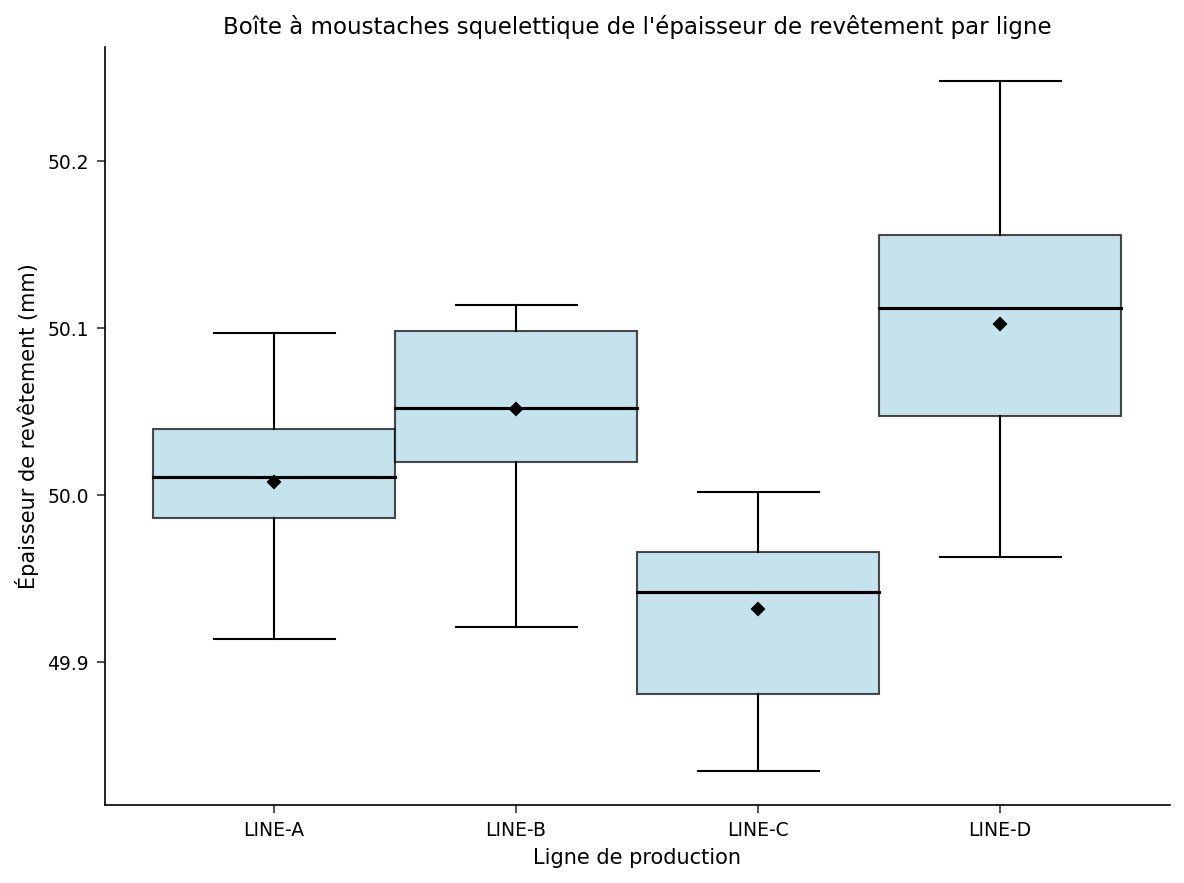

In [3]:
TITRE "Boîte à moustaches squelettique de l'épaisseur de revêtement par ligne";
PROCÉDURE boxplot DONNÉES=ProcessMeas;
   PLOT Thickness*Line;
EXÉCUTER;

## Étape 4 — Boîte à moustaches schématique

Nous passons à `BOXSTYLE=SCHEMATIC`. Dans le style schématique, chaque moustache est plafonnée à l'observation la plus extrême encore à l'intérieur des barrières de 1.5 × IQR, et tout point au-delà d'une barrière est tracé comme un marqueur de valeur aberrante individuelle. Dans cet échantillon, aucune ligne n'a de valeur aberrante hors barrière — la dispersion de chaque ligne est suffisamment compacte pour que les moustaches atteignent le vrai minimum et le vrai maximum — de sorte que le graphique schématique ressemble au graphique squelettique, ce qui est en soi un résultat utile : il indique à l'ingénieur qu'aucune des quatre lignes ne produit de pièces extrêmes. Les corps des boîtes rendent tout de même les décalages d'une ligne à l'autre évidents au premier coup d'œil, et l'étape 5 les quantifie par rapport aux limites de spécification.

                       Boîte à moustaches schématique SPC de l'épaisseur de revêtement par ligne                        

                     Boîte à moustaches schématique SPC de l'épaisseur de revêtement par ligne

                                                 The BOXPLOT Procedure

Schematic Plots for Épaisseur de revêtement (mm)

Ligne de production      N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINE-A               38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LINE-B               19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LINE-C               21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LINE-D               22        49.96        50.05        50.11        50.16        50.25


NOTE: Option TITLE changed to Boîte à moustaches schématique SPC de l'épaisseur de revêtement par ligne.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: ODS plot written: boxplot.spec.json


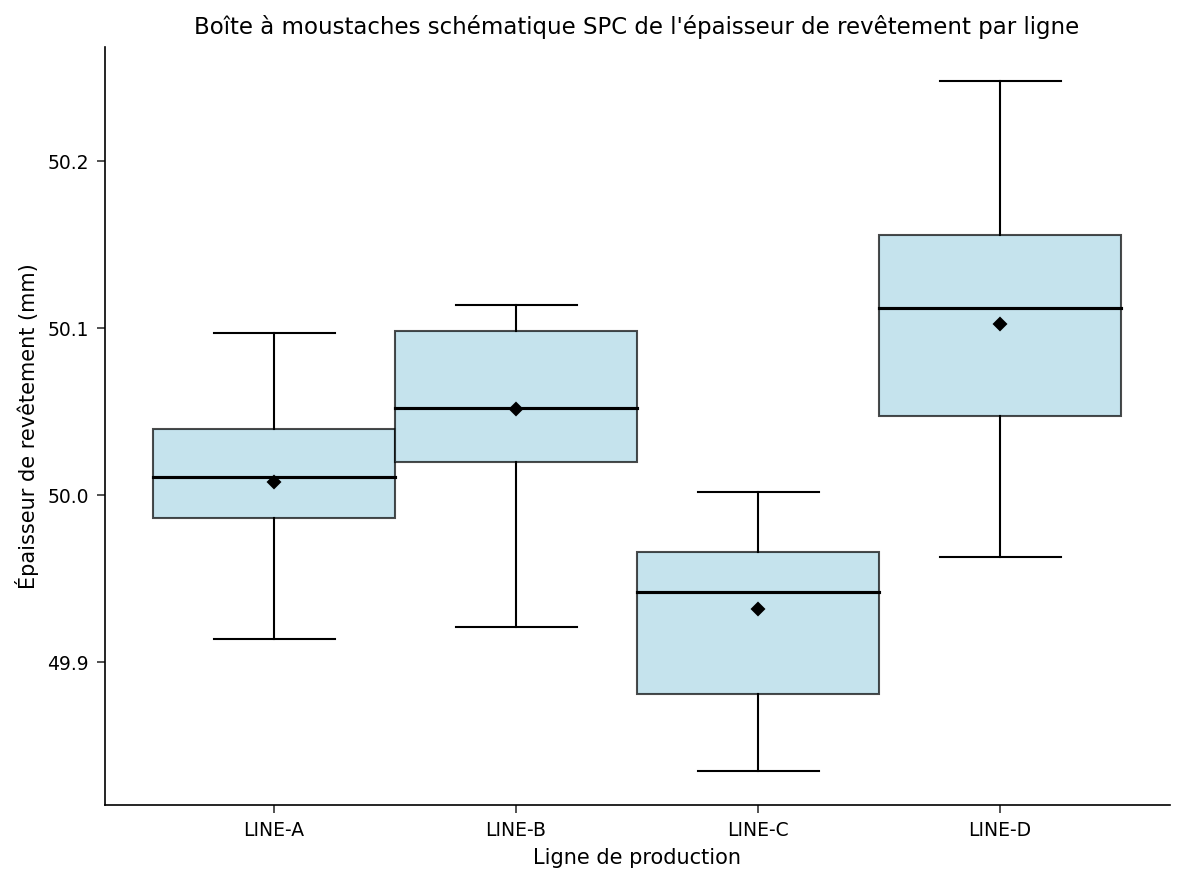

In [4]:
TITRE "Boîte à moustaches schématique SPC de l'épaisseur de revêtement par ligne";
PROCÉDURE boxplot DONNÉES=ProcessMeas;
   PLOT Thickness*Line / boxstyle=schematic;
EXÉCUTER;

## Étape 5 — Exporter les statistiques de boîte et évaluer par rapport aux limites de spécification

L'option `OUTBOX=` capture chaque statistique de boîte calculée dans un jeu de données — pour chaque ligne : la moustache basse (`L`), Q1 (`1`), la moyenne (`X`), la médiane (`M`), Q3 (`3`), la moustache haute (`H`), l'écart-type (`S`) et N. C'est le relevé numérique dont un auditeur a besoin derrière l'image, et c'est aussi le moyen le plus propre de vérifier chaque ligne par rapport à la spécification de 49.80 / 50.20 mm. Nous activons `GRID` pour une lecture plus facile, exportons `BoxStats`, l'imprimons, puis exécutons une courte étape DATA qui signale toute ligne dont l'étendue des moustaches dépasse une limite de spécification.

                         Boîte à moustaches schématique avec grille et export des statistiques                          

                        Boîte à moustaches schématique avec grille et export des statistiques

                                                 The BOXPLOT Procedure

Schematic Plots for Épaisseur de revêtement (mm)

Ligne de production      N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINE-A               38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LINE-B               19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LINE-C               21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LINE-D               22        49.96        50.05        50.11        50.16        50.25 


NOTE: Option TITLE changed to Boîte à moustaches schématique avec grille et export des statistiques.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: Output dataset BOXSTATS created with 4 observations.
NOTE: ODS plot written: boxplot.spec.json
NOTE: Option TITLE changed to Statistiques de boîte calculées (OUTBOX=).
NOTE: PROC PRINT data=BoxStats

NOTE: PROC PRINT completed: 4 observations printed, 9 variables
NOTE: DATA SpecCheck


NOTE: Read 4 rows from BoxStats.
NOTE: Wrote SpecCheck (4 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Évaluation par rapport aux limites de spécification par ligne.
NOTE: PROC PRINT data=SpecCheck

NOTE: PROC PRINT completed: 4 observations printed, 6 variables


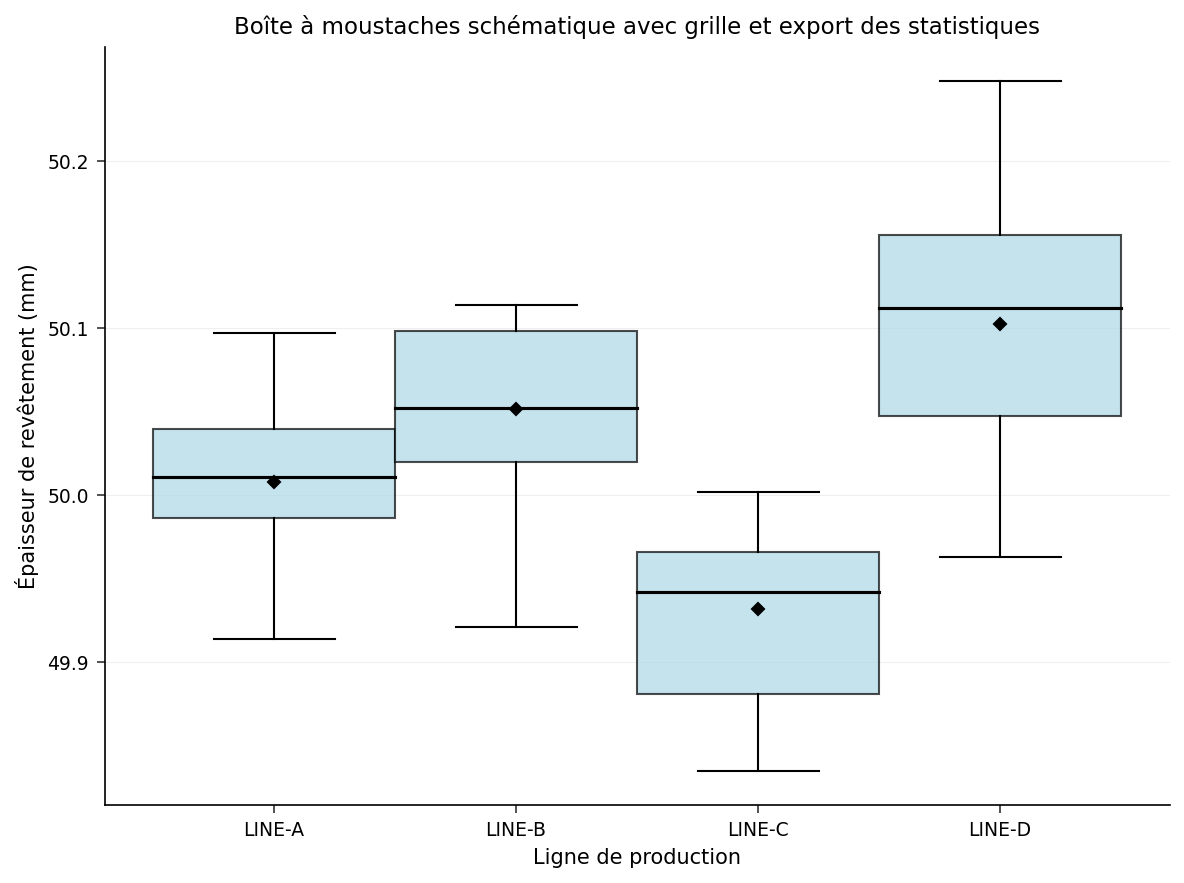

In [5]:
TITRE "Boîte à moustaches schématique avec grille et export des statistiques";
PROCÉDURE boxplot DONNÉES=ProcessMeas;
   PLOT Thickness*Line / boxstyle=schematic
                         grid
                         outbox=BoxStats;
EXÉCUTER;

TITRE "Statistiques de boîte calculées (OUTBOX=)";
PROCÉDURE IMPRIMER DONNÉES=BoxStats noobs;
EXÉCUTER;

/* Évaluer chaque ligne par rapport à la spécification 49.80 / 50.20 mm */
/* à l'aide des extrémités de moustaches exportées (THICKNESSL = moustache */
/* basse, THICKNESSH = moustache haute).                                   */
DONNÉES SpecCheck;
   DÉFINIR BoxStats;
   LONGUEUR Status $40;
   LSL = 49.80;
   USL = 50.20;
   SI THICKNESSH > USL ALORS Status = "Pièces hautes au-dessus de l'USL";
   SINON SI THICKNESSL < LSL ALORS Status = "Pièces basses sous la LSL";
   SINON Status = "Dans les spécifications";
   GARDER LINE THICKNESSL THICKNESSH LSL USL Status;
EXÉCUTER;

TITRE "Évaluation par rapport aux limites de spécification par ligne";
PROCÉDURE IMPRIMER DONNÉES=SpecCheck noobs;
EXÉCUTER;

## Étape 6 — Conserver un historique de surveillance et retracer à partir de celui-ci

En SPC continue, on réanalyse rarement chaque mesure brute. `OUTHISTORY=` écrit une ligne de synthèse par ligne de production (la même disposition que celle consommée par `HISTORY=`), de sorte que les données brutes volumineuses peuvent être archivées. Ci-dessous, nous exportons `LineHistory`, l'imprimons, puis prouvons l'aller-retour en le réinjectant directement dans un nouveau `PROC BOXPLOT` via `HISTORY=` — exactement comme un tableau de bord quotidien réutiliserait des statistiques de sous-groupes préagrégées.

                                        Export de l'historique des sous-groupes                                         

                                        Export de l'historique des sous-groupes

                                                 The BOXPLOT Procedure

Skeletal Plots for Épaisseur de revêtement (mm)

Ligne de production      N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINE-A               38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LINE-B               19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LINE-C               21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LINE-D               22        49.96        50.05        50.11        50.16        50.25        50.10   


NOTE: Option TITLE changed to Export de l'historique des sous-groupes.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: Output dataset LINEHISTORY created with 4 observations.
NOTE: ODS plot written: boxplot.spec.json
NOTE: Option TITLE changed to Jeu de données d'historique de synthèse (une ligne par ligne de production).
NOTE: PROC PRINT data=LineHistory

NOTE: PROC PRINT completed: 4 observations printed, 9 variables
NOTE: Option TITLE changed to Boîte à moustaches reconstruite à partir de l'historique de synthèse.
NOTE: PROC BOXPLOT history=LineHistory

NOTE: ODS plot written: boxplot.spec.json


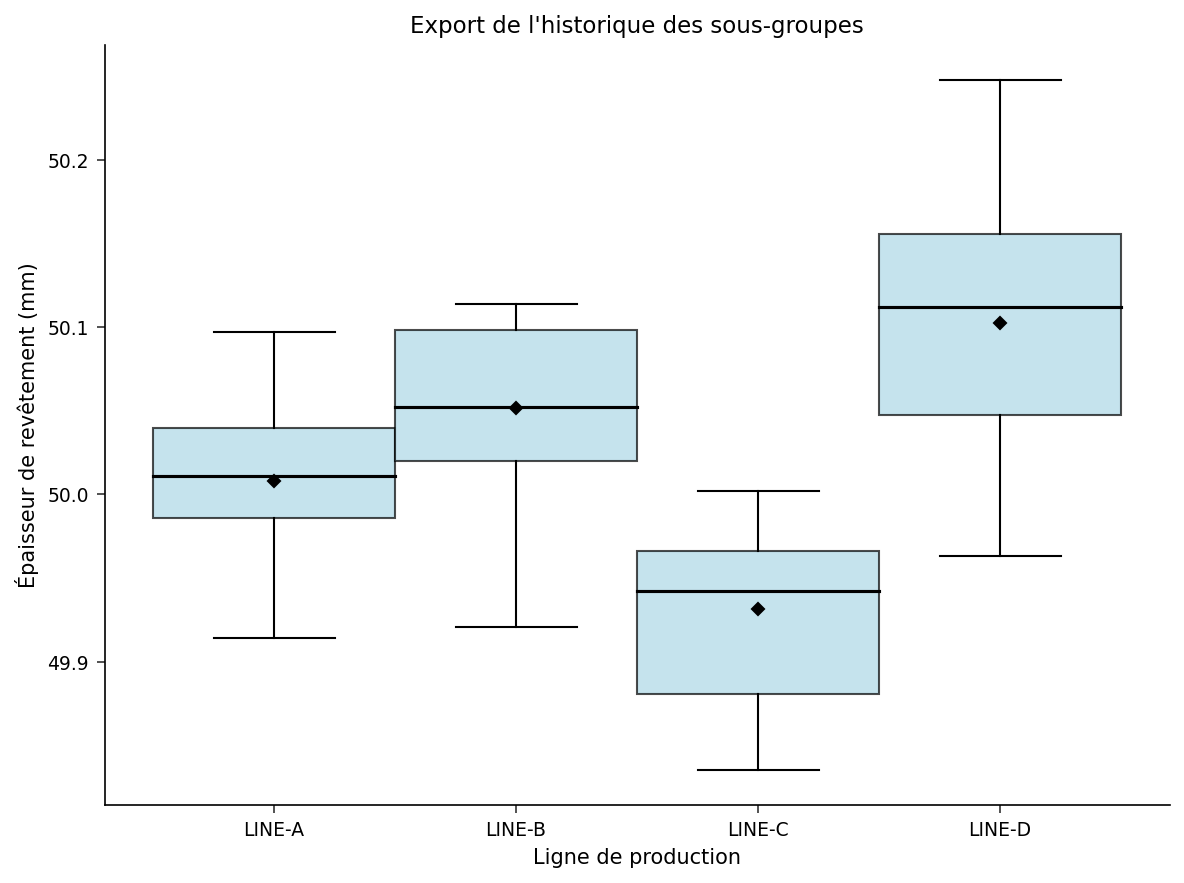

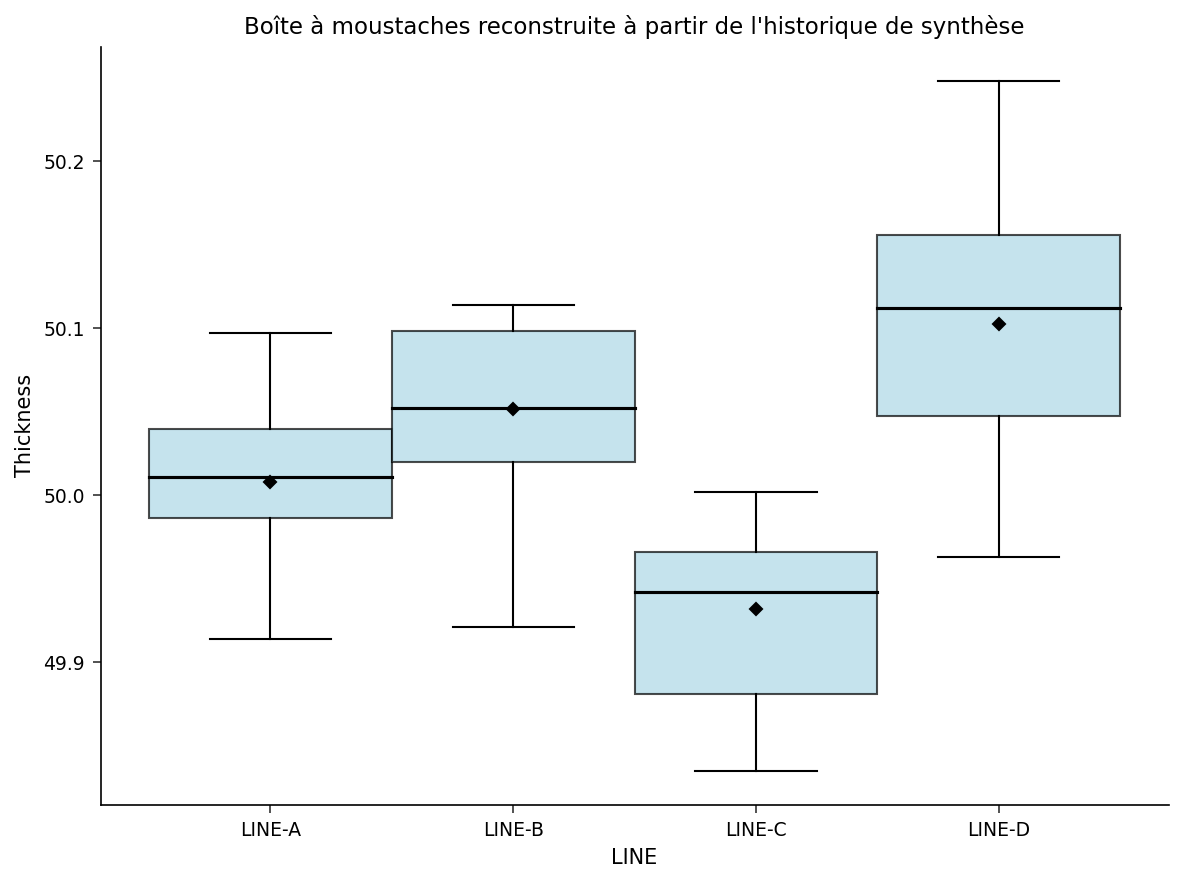

In [6]:
TITRE "Export de l'historique des sous-groupes";
PROCÉDURE boxplot DONNÉES=ProcessMeas;
   PLOT Thickness*Line / outhistory=LineHistory;
EXÉCUTER;

TITRE "Jeu de données d'historique de synthèse (une ligne par ligne de production)";
PROCÉDURE IMPRIMER DONNÉES=LineHistory noobs;
EXÉCUTER;

TITRE "Boîte à moustaches reconstruite à partir de l'historique de synthèse";
PROCÉDURE boxplot history=LineHistory;
   PLOT Thickness*Line;
EXÉCUTER;

## Interprétation des résultats

En lisant les boîtes à moustaches conjointement avec le profil `PROC MEANS`, le tableau `OUTBOX=` et l'évaluation des limites de spécification :

- **Centrage.** `LINE-A` est la mieux centrée sur la cible de 50.00 mm (moyenne 50.008 mm, médiane 50.011 mm). `LINE-B` tourne légèrement haut (moyenne 50.052 mm). `LINE-C` tourne bas (moyenne 49.932 mm, médiane 49.942 mm), la ligne dérivant vers la LSL. `LINE-D` tourne haut (moyenne 50.102 mm, médiane 50.112 mm), la ligne la plus proche de l'USL.
- **Dispersion.** `LINE-D` présente la boîte la plus large et les moustaches les plus longues — son écart-type de 0.080 mm est environ 60–80 % plus grand que celui des trois autres lignes (0.045–0.051 mm), la signalant comme la ligne la moins stable et la meilleure candidate pour une étude de réduction de la variation. `LINE-A` est la plus resserrée (écart-type 0.045 mm).
- **Queues.** En style schématique, aucune ligne ne produit de valeur aberrante hors barrière : chaque moustache atteint le vrai minimum/maximum de sa ligne, donc le procédé ne produit pas de pièces extrêmes isolées. Les différences de dispersion sont dues à la masse de chaque distribution, et non à des points isolés.
- **Conformité aux spécifications.** Les extrémités des moustaches `OUTBOX=`, évaluées par rapport à 49.80 / 50.20 mm, placent `LINE-A`, `LINE-B` et `LINE-C` entièrement **dans les spécifications**. `LINE-D` est l'exception : sa moustache haute atteint **50.248 mm**, au-delà de l'**USL de 50.20 mm** — les pièces hautes de `LINE-D` dépassent la spécification supérieure.
- **Mise en œuvre.** Le jeu de données `OUTBOX=` donne aux auditeurs les quartiles exacts, les extrémités des moustaches, la moyenne et l'écart-type derrière l'image, et `OUTHISTORY=` fournit une synthèse compacte et retraçable d'une ligne par ligne de production (étape 6) afin que le graphique puisse être régénéré selon un calendrier sans conserver les mesures brutes — la boîte à moustaches reconstruite à partir de la synthèse est identique à celle tracée à partir des données brutes.

**Actions à mener :** prioriser `LINE-D` — la recentrer à la fois vers le bas en direction de la cible et lancer une étude de réduction de la variation pour ramener sa moustache haute à l'intérieur de l'USL ; pousser `LINE-C` vers le haut en direction de la cible avant que sa queue basse n'atteigne la LSL ; `LINE-A` et `LINE-B` fonctionnent de façon acceptable.